# Estimating Time to Payment for Receivables


Analyzing company data and Bureau data. Combining them with Assets Duration table for further analysis


In [1]:
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
import sys

sys.path.append("../")

from case.helper_functions import plot_km_curve_category, create_duration_table

pd.set_option('display.max_columns', None)


Company data has a tax_id per row so it does not need to be deduplicated, we check this in the next cells. and the join it to our duration table

In [2]:
company = pd.read_parquet("../data/df_company_data.parquet", engine="pyarrow")
company.head()

,tax_id,company_status,company_status_date,company_creation_date,company_size,main_cnae,main_cnae_description,secondary_cnae_array,legal_nature,is_mei,city,state,zipcode
7,87385337719617,Ativa,2006-06-07,2006-06-07,Demais,2621300,Fabricação de equipamentos de informática,"[{""classe"":""26.22-1"",""descricao"":""Fabricação d...",Sociedade Empresária Limitada,False,João Pessoa,Paraíba,58028870
9,48307533985873,Ativa,2016-09-29,2016-09-29,Demais,4639701,Comércio atacadista de produtos alimentícios e...,"[{""classe"":""46.49-4"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Campo Grande,Mato Grosso do Sul,79009030
10,02003411654784,Ativa,2011-03-25,2011-03-25,Demais,4651602,Comércio atacadista de suprimentos para inform...,"[{""classe"":""46.47-8"",""descricao"":""Comércio ata...",Sociedade Simples Limitada,False,Rio de Janeiro,Rio de Janeiro,21032900
12,31629860033682,Ativa,2015-10-08,2015-10-08,Micro Empresa,4651601,Comércio atacadista de equipamentos de informá...,"[{""classe"":""47.51-2"",""descricao"":""Comércio var...",Sociedade Empresária Limitada,False,Belo Horizonte,Minas Gerais,30160040
13,85030704409437,Ativa,2022-02-28,2000-07-13,Demais,4651601,Comércio atacadista de equipamentos de informá...,"[{""classe"":""46.51-6"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,São José dos Campos,São Paulo,12231820


In [3]:
company.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76893 entries, 7 to 145985
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   tax_id                 76893 non-null  object
 1   company_status         76194 non-null  object
 2   company_status_date    75359 non-null  object
 3   company_creation_date  76194 non-null  object
 4   company_size           76194 non-null  object
 5   main_cnae              76194 non-null  object
 6   main_cnae_description  76194 non-null  object
 7   secondary_cnae_array   76893 non-null  object
 8   legal_nature           76194 non-null  object
 9   is_mei                 76893 non-null  bool  
 10  city                   76194 non-null  object
 11  state                  76194 non-null  object
 12  zipcode                76194 non-null  object
dtypes: bool(1), object(12)
memory usage: 7.7+ MB


In [4]:
company.tax_id.nunique()

76893

In [5]:
assets = pd.read_parquet('../data/df_assets.parquet', engine="pyarrow")
assets_duration = create_duration_table(assets)
assets_duration.head()

,asset_id,seller_tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment,cohort_month,cohort_year
0,5c764ad8-59dc-e30a-9d73-b051582605fb,60259422305974,534.41,2025-03-13,2025-04-06,2025-04-10,2025-04-15,24.0,1,0,2025Q1,2025
1,b947a6c4-6e17-a418-091d-c04952f85047,00925347588806,165.14,2024-12-03,2024-12-22,2024-12-24,2025-03-19,19.0,1,0,2024Q4,2024
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,14133781557079,432.55,2024-01-26,2024-02-01,2024-02-02,2025-03-20,6.0,1,0,2024Q1,2024
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,14133781557079,102.60,2023-02-28,2023-03-07,2023-03-08,2025-03-20,7.0,1,0,2023Q1,2023
4,3ee1a83eb0ba837d,87924474238085,6739.70,2024-06-24,2024-08-06,2024-08-08,2025-02-03,43.0,1,0,2024Q2,2024


Now, a join is made between company data and assets duration_table using seller_tax_id (anonymized CNPJ). About 54% of seller_tax_id were not found in the company data table. As these null values are not random, I decided to use them as separate category for analysis and implementation of the time to payment model.

In [6]:
assets_duration = assets_duration.rename(columns={"seller_tax_id": "tax_id"})
assets_duration_company = assets_duration.merge(company, on="tax_id", how="left")
assets_duration_company.head()

,asset_id,tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment,cohort_month,cohort_year,company_status,company_status_date,company_creation_date,company_size,main_cnae,main_cnae_description,secondary_cnae_array,legal_nature,is_mei,city,state,zipcode
0,5c764ad8-59dc-e30a-9d73-b051582605fb,60259422305974,534.41,2025-03-13,2025-04-06,2025-04-10,2025-04-15,24.0,1,0,2025Q1,2025,Ativa,2004-10-16,2002-09-30,Demais,4644301,Comércio atacadista de medicamentos e drogas d...,"[{""classe"":""46.37-1"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Trindade,Goiás,75384618
1,b947a6c4-6e17-a418-091d-c04952f85047,00925347588806,165.14,2024-12-03,2024-12-22,2024-12-24,2025-03-19,19.0,1,0,2024Q4,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,14133781557079,432.55,2024-01-26,2024-02-01,2024-02-02,2025-03-20,6.0,1,0,2024Q1,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,14133781557079,102.60,2023-02-28,2023-03-07,2023-03-08,2025-03-20,7.0,1,0,2023Q1,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3ee1a83eb0ba837d,87924474238085,6739.70,2024-06-24,2024-08-06,2024-08-08,2025-02-03,43.0,1,0,2024Q2,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
assets_duration_company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980178 entries, 0 to 980177
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   asset_id               980178 non-null  object        
 1   tax_id                 980178 non-null  object        
 2   face_value             980178 non-null  float64       
 3   created_at             980178 non-null  datetime64[ns]
 4   settled_at             868146 non-null  datetime64[ns]
 5   due_date               980178 non-null  datetime64[ns]
 6   reference_date         980178 non-null  datetime64[ns]
 7   duration_days          980178 non-null  float64       
 8   paid                   980178 non-null  int64         
 9   late_payment           980178 non-null  int64         
 10  cohort_month           980178 non-null  object        
 11  cohort_year            980178 non-null  object        
 12  company_status         439254 non-null  obje

The function below creates the pipeline to join duration and company data, then fill all null values of the merged dataset with the string "NULL" and they are analyzed separated from the match population onwards. This function is referred in the **../case/helper_functions.py** module as well.
In order to track sellers without any information a new column "has_company_information" is set as well.

In [8]:
df = assets_duration.rename(columns={"seller_tax_id":"tax_id"})

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980178 entries, 0 to 1001022
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   asset_id        980178 non-null  object        
 1   tax_id          980178 non-null  object        
 2   face_value      980178 non-null  float64       
 3   created_at      980178 non-null  datetime64[ns]
 4   settled_at      868146 non-null  datetime64[ns]
 5   due_date        980178 non-null  datetime64[ns]
 6   reference_date  980178 non-null  datetime64[ns]
 7   duration_days   980178 non-null  float64       
 8   paid            980178 non-null  int64         
 9   late_payment    980178 non-null  int64         
 10  cohort_month    980178 non-null  object        
 11  cohort_year     980178 non-null  object        
dtypes: datetime64[ns](4), float64(2), int64(2), object(4)
memory usage: 97.2+ MB


In [10]:
company

,tax_id,company_status,company_status_date,company_creation_date,company_size,main_cnae,main_cnae_description,secondary_cnae_array,legal_nature,is_mei,city,state,zipcode
7,87385337719617,Ativa,2006-06-07,2006-06-07,Demais,2621300,Fabricação de equipamentos de informática,"[{""classe"":""26.22-1"",""descricao"":""Fabricação d...",Sociedade Empresária Limitada,False,João Pessoa,Paraíba,58028870
9,48307533985873,Ativa,2016-09-29,2016-09-29,Demais,4639701,Comércio atacadista de produtos alimentícios e...,"[{""classe"":""46.49-4"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Campo Grande,Mato Grosso do Sul,79009030
10,02003411654784,Ativa,2011-03-25,2011-03-25,Demais,4651602,Comércio atacadista de suprimentos para inform...,"[{""classe"":""46.47-8"",""descricao"":""Comércio ata...",Sociedade Simples Limitada,False,Rio de Janeiro,Rio de Janeiro,21032900
12,31629860033682,Ativa,2015-10-08,2015-10-08,Micro Empresa,4651601,Comércio atacadista de equipamentos de informá...,"[{""classe"":""47.51-2"",""descricao"":""Comércio var...",Sociedade Empresária Limitada,False,Belo Horizonte,Minas Gerais,30160040
13,85030704409437,Ativa,2022-02-28,2000-07-13,Demais,4651601,Comércio atacadista de equipamentos de informá...,"[{""classe"":""46.51-6"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,São José dos Campos,São Paulo,12231820
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145907,41936053577490,Ativa,2023-01-17,2023-01-17,Micro Empresa,9521500,Reparação e manutenção de equipamentos eletroe...,"[{""classe"":""47.57-1"",""descricao"":""Comércio var...",Sociedade Empresária Limitada,False,São Paulo,São Paulo,02739000
145920,87428026028020,Ativa,2015-08-06,2015-08-06,Micro Empresa,9521500,Reparação e manutenção de equipamentos eletroe...,"[{""classe"":""47.57-1"",""descricao"":""Comércio var...",Sociedade Empresária Limitada,False,Londrina,Paraná,86026020
145923,81675436624111,Ativa,2000-12-23,1975-03-21,Micro Empresa,9521500,Reparação e manutenção de equipamentos eletroe...,[],Sociedade Empresária Limitada,False,Bauru,São Paulo,17015130
145973,53742485378127,Ativa,2005-11-03,1995-03-02,Empresa de Pequeno Porte,9521500,Reparação e manutenção de equipamentos eletroe...,"[{""classe"":""47.53-9"",""descricao"":""Comércio var...",Sociedade Empresária Limitada,False,Caxias do Sul,Rio Grande do Sul,95032460


In [11]:
def add_company_info(duration, company):
    """
    Add company info information to duration table.
    Converts company-related columns to object dtype,
    fills missing with 'NULL', and adds 'has_company_info'
    indicating whether at least one company field was originally present.
    If no information about the seller is present than 'has_company_info' gets 0, 1 otherwise
    """
    df = duration.rename(columns={"seller_tax_id":"tax_id"})
    df = df.merge(company, on='tax_id', how='left')
    company_cols = [
        "company_status",
        "company_status_date",
        "company_creation_date",
        "company_size",
        "main_cnae",
        "main_cnae_description",
        "secondary_cnae_array",
        "legal_nature",
        "is_mei",
        "city",
        "state",
        "zipcode",
    ]

    df = df.copy()


    existing_cols = [col for col in company_cols if col in df.columns]

    df["has_company_info"] = df[existing_cols].notna().any(axis=1).astype(int)

    for col in existing_cols:
        df[col] = df[col].astype(object).fillna("NULL")

    return df

In [12]:
assets_duration_company = add_company_info(assets_duration, company)

---

After data cleaning, we will move on a stratified analysis of Kaplan-Meier curves of the duration table, analyzing the performance of payments for different groups and infering if some of these data might be a good candidate for predictive modeling on time to payment. The Kaplan-Meier plots are generated in the same way it was done on the preliminary analysis. Function code is also in the helper_functions module as well

looking at company status field, we see that almost all companies which contain information are "active", a very small number of them are inactive (which are not well represented for comparison) and the remaing do not have information.

It can be seen that sellers with company information available are consistently better payers than the ones without it, with a smoother decay on survival probabilitiies 

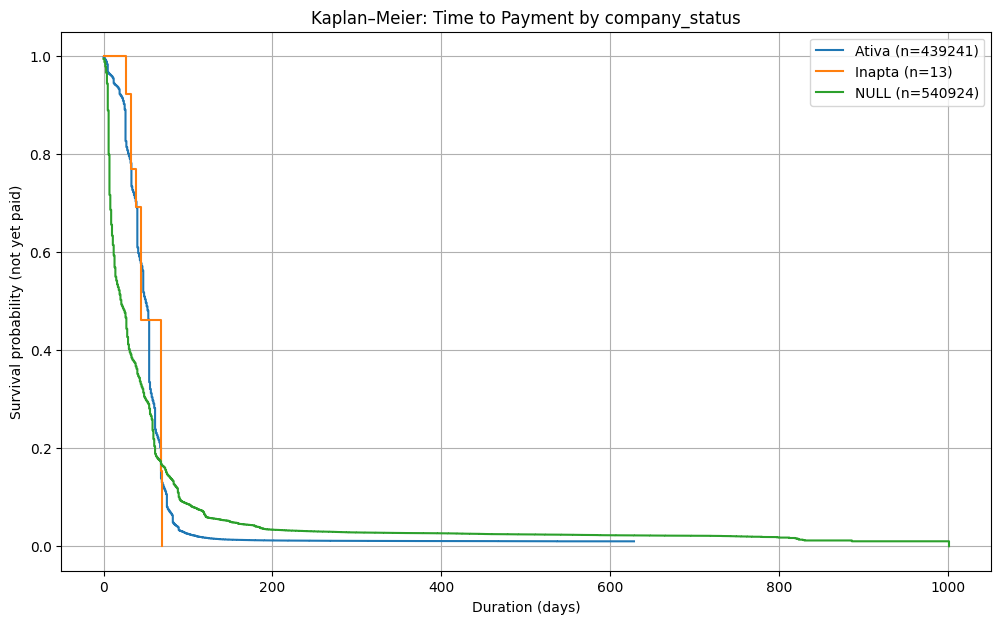

['Ativa', 'Inapta', 'NULL']

In [13]:
plot_km_curve_category("company_status", assets_duration_company)

---

All sellers having company information has the "Sociedade Empresária Limitada" description in legal nature. It clear can be seen that sellers  with known information are less risk than the ones without it. 

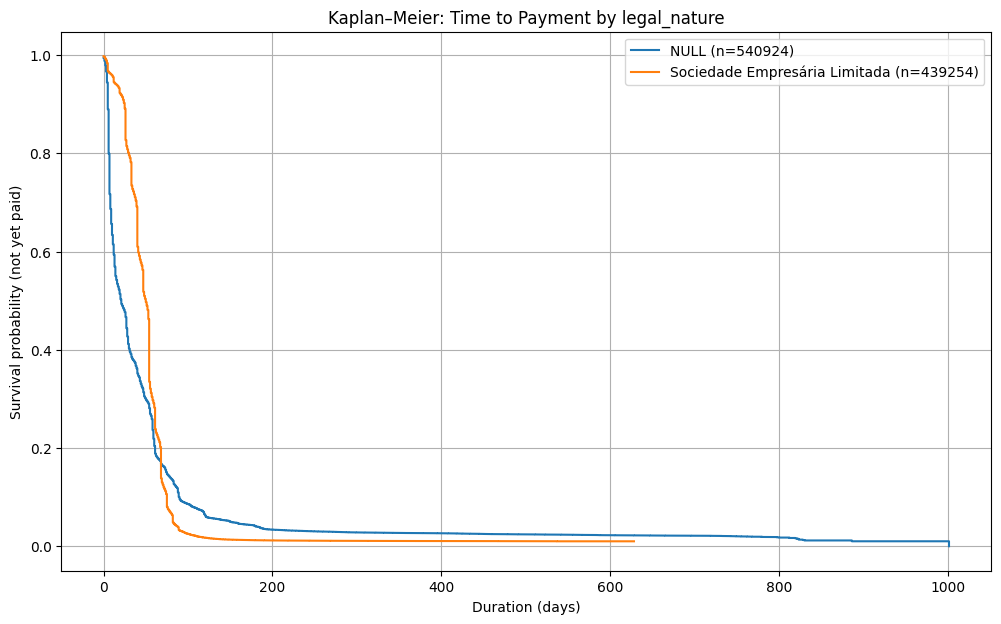

['NULL', 'Sociedade Empresária Limitada']

In [14]:
plot_km_curve_category("legal_nature", assets_duration_company)

As long as "legal nature" per se is not informative, as it has only one category, it can clearly be seen that if a seller has any information on company registration, the default risk is significantly lower than the ones without it.

As expected "has_company_info" stratification brings the same information on "legal_nature". The former field will be kept for further analysis

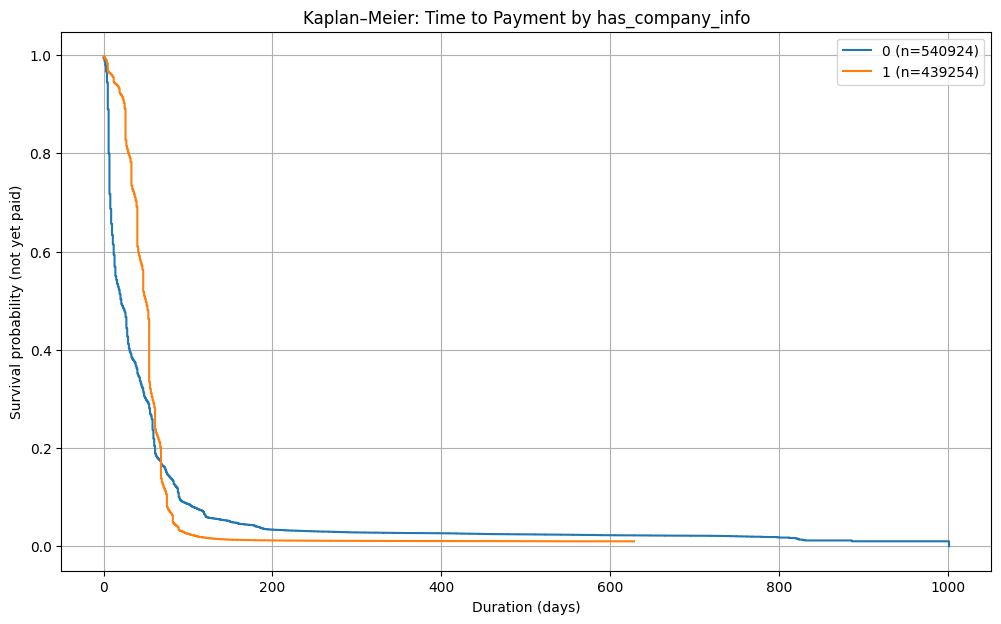

[0, 1]

In [15]:
plot_km_curve_category("has_company_info", assets_duration_company)

---

All sellers that have company data are not MEI ("individual micro-entrepreneur", low revenue companies in Brazil). It can not be infered that companies without this information are MEI or not, but it can be seen again, that companies having this field in register offer lower risk. 
As we can not infer the nature of the company without data (if it is MEI or not), this information will not be used for further modeling.


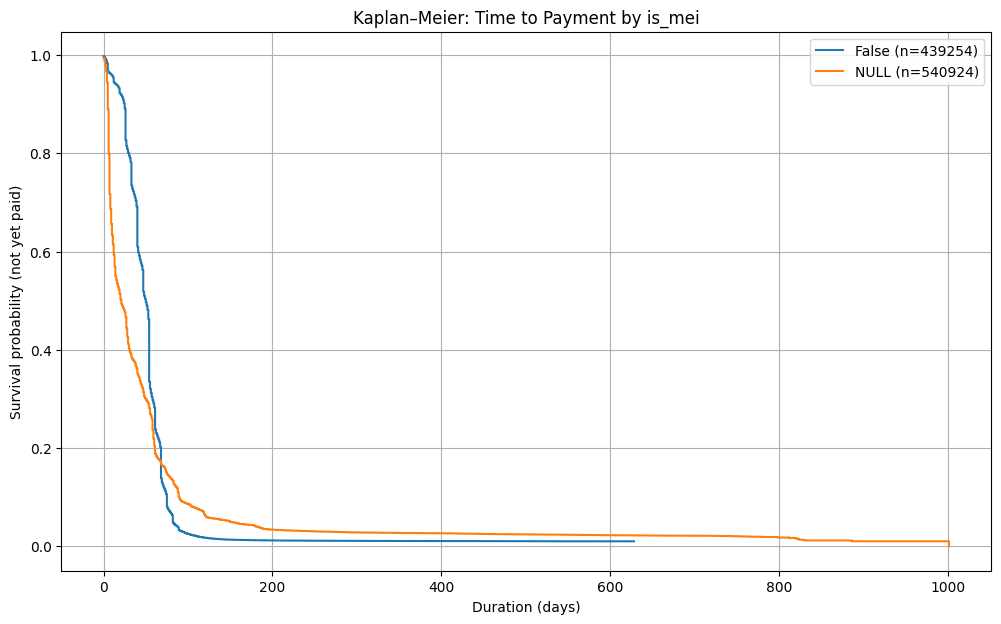

[False, 'NULL']

In [16]:
plot_km_curve_category("is_mei",assets_duration_company)

---

Analyzing "company size" with see two major groups: the one with no data and others with a generic description "Demais". We see again the same profile for companies with  corporate registration having lower risk than companies without it. Also two trace groups "Empresa de Pequeno Parte" e "Micro Empresa" appear in company data, but they are not representative.

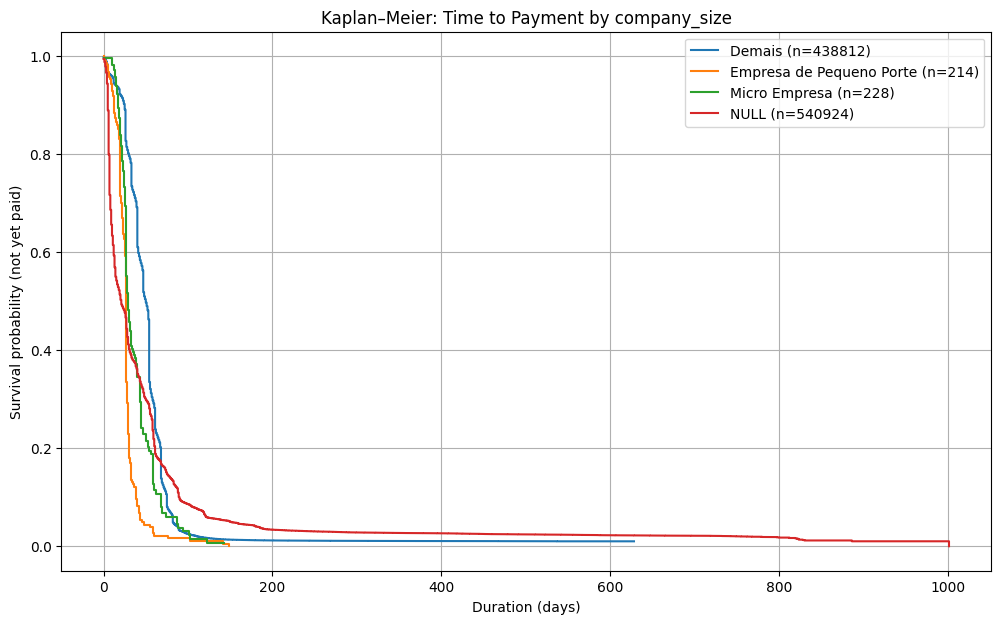

['Demais', 'Empresa de Pequeno Porte', 'Micro Empresa', 'NULL']

In [17]:
plot_km_curve_category("company_size", assets_duration_company)

Agrouping the smallest groups of "company_size" in "Demais" category and doing the Kapla-Meier estimate again, we see the same profile for "has_company_info" segment

In [18]:
counts = assets_duration_company['company_size'].value_counts()

minor_categories = counts[(counts < 1000) & (~counts.index.isin(["NULL", "Demais"]))].index

assets_duration_company['company_size'] = assets_duration_company['company_size'].replace(minor_categories, "Demais")

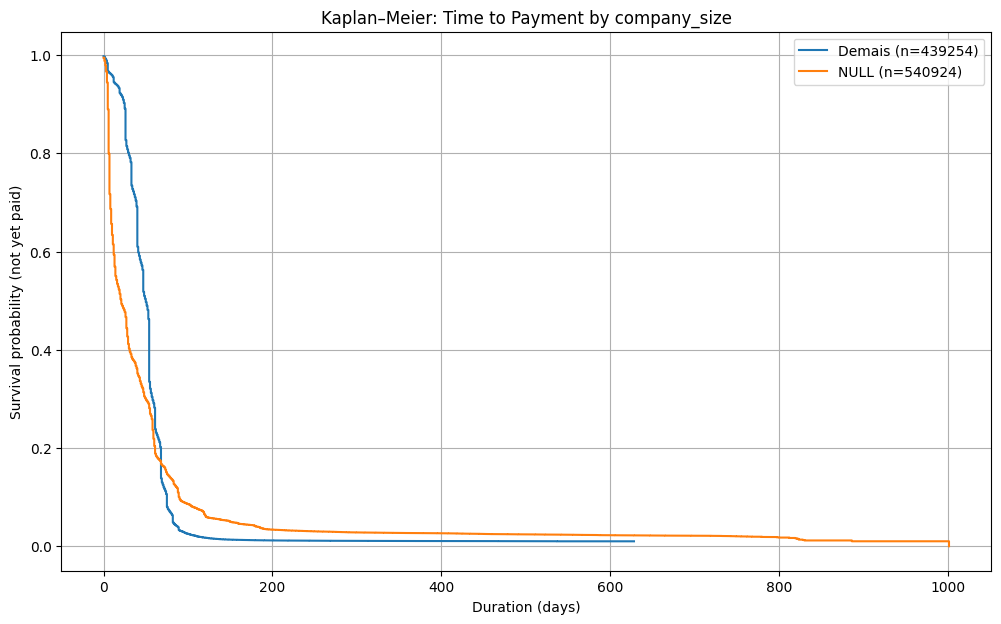

['Demais', 'NULL']

In [19]:
plot_km_curve_category("company_size", assets_duration_company)

As such "company_size" will not be used for further modeling of time to payment

---

Going for economic activity analysis using CNAE ("Cadastro nacional de Atividade Econômica") description 

In [20]:
assets_duration_company.main_cnae_description.value_counts()

main_cnae_description
NULL                                                                                                       540924
Comércio atacadista de medicamentos e drogas de uso humano                                                 419540
Comércio a varejo de peças e acessórios novos para veículos automotores                                     11871
Comércio varejista de cosméticos, produtos de perfumaria e de higiene pessoal                                4116
Comércio atacadista de produtos alimentícios em geral                                                        1931
Frigorífico - abate de bovinos                                                                               1363
Fabricação de produtos farmoquímicos                                                                          125
Comércio atacadista de cerveja, chope e refrigerante                                                           64
Comércio atacadista de mercadorias em geral, sem predominância de 

In [21]:
# group main_cnae_description categories with <=1000 occurrences into 'nulo'
counts = assets_duration_company['main_cnae_description'].value_counts()
rare_idx = counts[counts <= 1000].index

# ensure dtype and fill missing before replacing
assets_duration_company['main_cnae_description'] = (
    assets_duration_company['main_cnae_description']
    .astype(object)
    .fillna('NULL')
)

assets_duration_company.loc[
    assets_duration_company['main_cnae_description'].isin(rare_idx),
    'main_cnae_description'
] = 'Demais'

# quick sanity check
assets_duration_company['main_cnae_description'].value_counts().head(20)

main_cnae_description
NULL                                                                             540924
Comércio atacadista de medicamentos e drogas de uso humano                       419540
Comércio a varejo de peças e acessórios novos para veículos automotores           11871
Comércio varejista de cosméticos, produtos de perfumaria e de higiene pessoal      4116
Comércio atacadista de produtos alimentícios em geral                              1931
Frigorífico - abate de bovinos                                                     1363
Demais                                                                              433
Name: count, dtype: int64

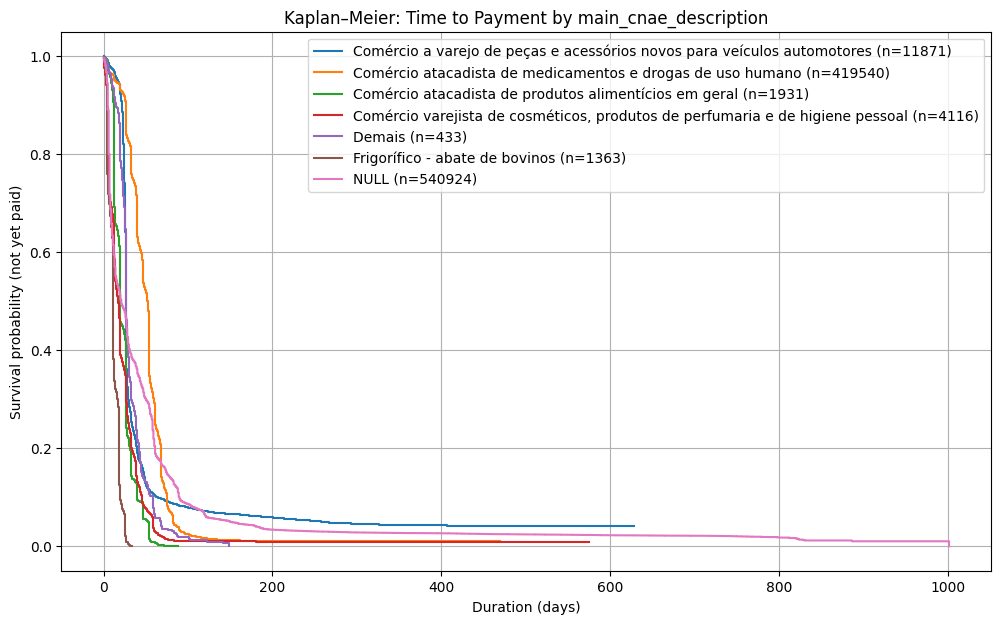

['Comércio a varejo de peças e acessórios novos para veículos automotores',
 'Comércio atacadista de medicamentos e drogas de uso humano',
 'Comércio atacadista de produtos alimentícios em geral',
 'Comércio varejista de cosméticos, produtos de perfumaria e de higiene pessoal',
 'Demais',
 'Frigorífico - abate de bovinos',
 'NULL']

In [22]:
plot_km_curve_category("main_cnae_description", assets_duration_company)

---

In [23]:
assets_duration_company.state.value_counts()

state
NULL              540924
Goiás             419540
São Paulo          16079
Minas Gerais        3488
Rio de Janeiro        72
Santa Catarina        63
Paraná                10
Pernambuco             1
Bahia                  1
Name: count, dtype: int64

In [24]:
# group state categories with <=1000 occurrences into 'Demais'
counts_state = assets_duration_company["state"].value_counts()
rare_states = counts_state[counts_state <= 1000].index

assets_duration_company["state"] = (
    assets_duration_company["state"].astype(object).fillna("NULL")
)

assets_duration_company.loc[
    assets_duration_company["state"].isin(rare_states), "state"
] = "Demais"

# quick sanity check
assets_duration_company["state"].value_counts()

state
NULL            540924
Goiás           419540
São Paulo        16079
Minas Gerais      3488
Demais             147
Name: count, dtype: int64

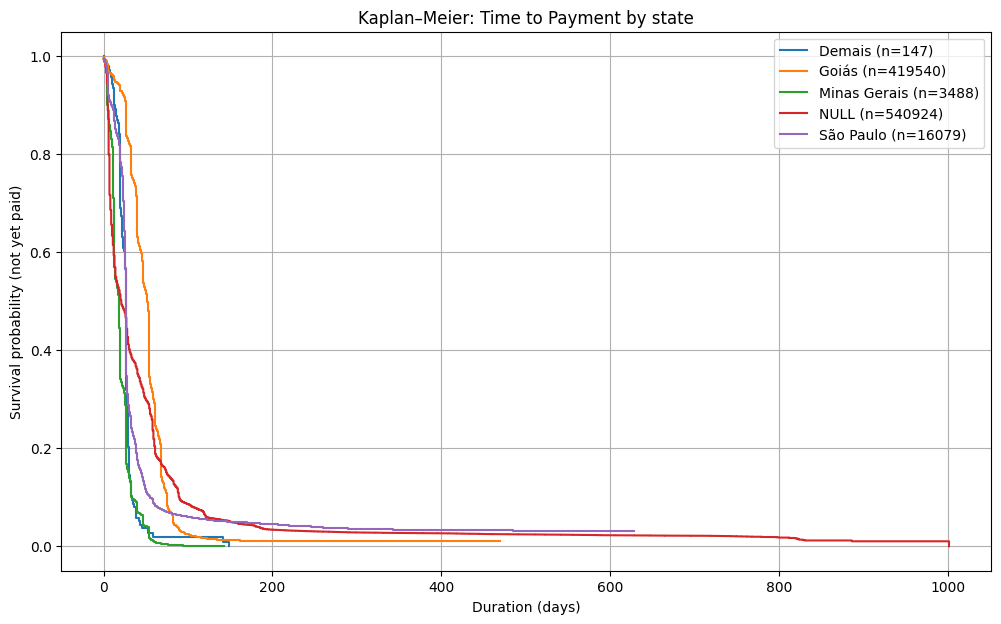

['Demais', 'Goiás', 'Minas Gerais', 'NULL', 'São Paulo']

In [25]:
plot_km_curve_category("state", assets_duration_company)

for future reuse in modeling, a function is created to group rare categories with less than 1000 records

In [1]:
def group_rare_categories(df, column_name):
    """
    Group categories with low frequency (less than 1000 records by default)
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame s
    column_name : str
       column to be processed

    Returns:
    --------
    DataFrame
        DataFrame com a coluna modificada
    """
    
    df = df.copy()    
   
    counts = df[column_name].value_counts()
    rare_categories = counts[counts <= 1000].index
    
    df.loc[df[column_name].isin(rare_categories), column_name] = 'Demais'
    
    return df

---

Next, Bureau (Quod) data is incoporated in our enriched duration table with company data! We have two informations provided by the bureau: a credit score, ranging from 0 to 1000 and presumed_revenue of the company bases on bureau data.

In [26]:
quod = pd.read_parquet('../data/df_quod.parquet', engine='pyarrow')

Investing this dataset, we see that there are duplicates in the tax_id key.

In [27]:
quod.sort_values('tax_id', ascending= True)

,tax_id,quod_score,presumed_revenue,created_at
33584,00002068551693,377.0,596339.14,2025-02-13 13:34:55.570200
50265,00004617334254,858.0,1828310.55,2025-04-09 21:01:51.048985
50722,00004617334254,858.0,1781921.03,2025-07-12 00:02:06.718342
81440,00006098134080,970.0,4774746.48,2025-04-16 15:08:25.202310
107260,00006243655497,920.0,735351.22,2025-03-25 22:44:41.303767
...,...,...,...,...
61387,99993288797588,1000.0,1148794.62,2025-03-26 05:10:40.317552
48327,99993479907043,877.0,549518.39,2024-12-06 17:45:16.305551
30564,99994507966870,751.0,59695.55,2025-03-27 17:24:36.543750
79486,99996658881263,885.0,880937.99,2024-12-18 05:29:00.485706


Here we deduplicate to get the most recent record from quod table

In [28]:
quod = quod.loc[quod.groupby("tax_id")["created_at"].idxmax()].drop('created_at', axis=1)
quod.head()

,tax_id,quod_score,presumed_revenue
33584,00002068551693,377.0,5.963391e+05
50722,00004617334254,858.0,1.781921e+06
81440,00006098134080,970.0,4.774746e+06
107260,00006243655497,920.0,7.353512e+05
42618,00006840518062,898.0,1.127704e+08


In [29]:
quod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43062 entries, 33584 to 3811
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tax_id            43062 non-null  object 
 1   quod_score        43053 non-null  float64
 2   presumed_revenue  42818 non-null  float64
dtypes: float64(2), object(1)
memory usage: 1.3+ MB


In [30]:
assets_duration_all = assets_duration_company.merge(quod, on='tax_id', how='left')
assets_duration_all.head()

,asset_id,tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment,cohort_month,cohort_year,company_status,company_status_date,company_creation_date,company_size,main_cnae,main_cnae_description,secondary_cnae_array,legal_nature,is_mei,city,state,zipcode,has_company_info,quod_score,presumed_revenue
0,5c764ad8-59dc-e30a-9d73-b051582605fb,60259422305974,534.41,2025-03-13,2025-04-06,2025-04-10,2025-04-15,24.0,1,0,2025Q1,2025,Ativa,2004-10-16,2002-09-30,Demais,4644301,Comércio atacadista de medicamentos e drogas d...,"[{""classe"":""46.37-1"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Trindade,Goiás,75384618,1,920.0,1.286888e+08
1,b947a6c4-6e17-a418-091d-c04952f85047,00925347588806,165.14,2024-12-03,2024-12-22,2024-12-24,2025-03-19,19.0,1,0,2024Q4,2024,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0,NaN,NaN
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,14133781557079,432.55,2024-01-26,2024-02-01,2024-02-02,2025-03-20,6.0,1,0,2024Q1,2024,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0,NaN,NaN
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,14133781557079,102.60,2023-02-28,2023-03-07,2023-03-08,2025-03-20,7.0,1,0,2023Q1,2023,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0,NaN,NaN
4,3ee1a83eb0ba837d,87924474238085,6739.70,2024-06-24,2024-08-06,2024-08-08,2025-02-03,43.0,1,0,2024Q2,2024,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0,NaN,NaN


In [31]:
assets_duration_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980178 entries, 0 to 980177
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   asset_id               980178 non-null  object        
 1   tax_id                 980178 non-null  object        
 2   face_value             980178 non-null  float64       
 3   created_at             980178 non-null  datetime64[ns]
 4   settled_at             868146 non-null  datetime64[ns]
 5   due_date               980178 non-null  datetime64[ns]
 6   reference_date         980178 non-null  datetime64[ns]
 7   duration_days          980178 non-null  float64       
 8   paid                   980178 non-null  int64         
 9   late_payment           980178 non-null  int64         
 10  cohort_month           980178 non-null  object        
 11  cohort_year            980178 non-null  object        
 12  company_status         980178 non-null  obje

As it was seen in company data, there are loads of missing data for companies coming also from an external bureau. For all these cases, presumed_revenue and quod_score get the label -1, as they are numerical features. They will be treated separatedely on further analysis. I've also made a flag 'has_quod_info', being 1 if there is one information in the quod dataset.

In [32]:

for i in ['quod_score', 'presumed_revenue']:
    assets_duration_all['quod_score'] = np.where(assets_duration_all['quod_score'].isna(), -1, assets_duration_all['quod_score'])
    assets_duration_all['presumed_revenue'] = np.where(assets_duration_all['presumed_revenue'].isna(), -1, assets_duration_all['presumed_revenue'])
assets_duration_all['has_quod_info'] = np.where ((assets_duration_all['quod_score'] == -1) & (assets_duration_all['presumed_revenue'] == -1) , 0, 1)


In [33]:
assets_duration_all.head()

,asset_id,tax_id,face_value,created_at,settled_at,due_date,reference_date,duration_days,paid,late_payment,cohort_month,cohort_year,company_status,company_status_date,company_creation_date,company_size,main_cnae,main_cnae_description,secondary_cnae_array,legal_nature,is_mei,city,state,zipcode,has_company_info,quod_score,presumed_revenue,has_quod_info
0,5c764ad8-59dc-e30a-9d73-b051582605fb,60259422305974,534.41,2025-03-13,2025-04-06,2025-04-10,2025-04-15,24.0,1,0,2025Q1,2025,Ativa,2004-10-16,2002-09-30,Demais,4644301,Comércio atacadista de medicamentos e drogas d...,"[{""classe"":""46.37-1"",""descricao"":""Comércio ata...",Sociedade Empresária Limitada,False,Trindade,Goiás,75384618,1,920.0,1.286888e+08,1
1,b947a6c4-6e17-a418-091d-c04952f85047,00925347588806,165.14,2024-12-03,2024-12-22,2024-12-24,2025-03-19,19.0,1,0,2024Q4,2024,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0,-1.0,-1.000000e+00,0
2,a314edf1-9bf6-6d6c-bca5-55d1349b19d5,14133781557079,432.55,2024-01-26,2024-02-01,2024-02-02,2025-03-20,6.0,1,0,2024Q1,2024,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0,-1.0,-1.000000e+00,0
3,c9877d94-5168-849f-42f7-3bf4ef46bf31,14133781557079,102.60,2023-02-28,2023-03-07,2023-03-08,2025-03-20,7.0,1,0,2023Q1,2023,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0,-1.0,-1.000000e+00,0
4,3ee1a83eb0ba837d,87924474238085,6739.70,2024-06-24,2024-08-06,2024-08-08,2025-02-03,43.0,1,0,2024Q2,2024,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0,-1.0,-1.000000e+00,0


The variable "has quod_info" is very closely related to the previously created and important feature "has_company_info", so it will not be kept for modeling purposes

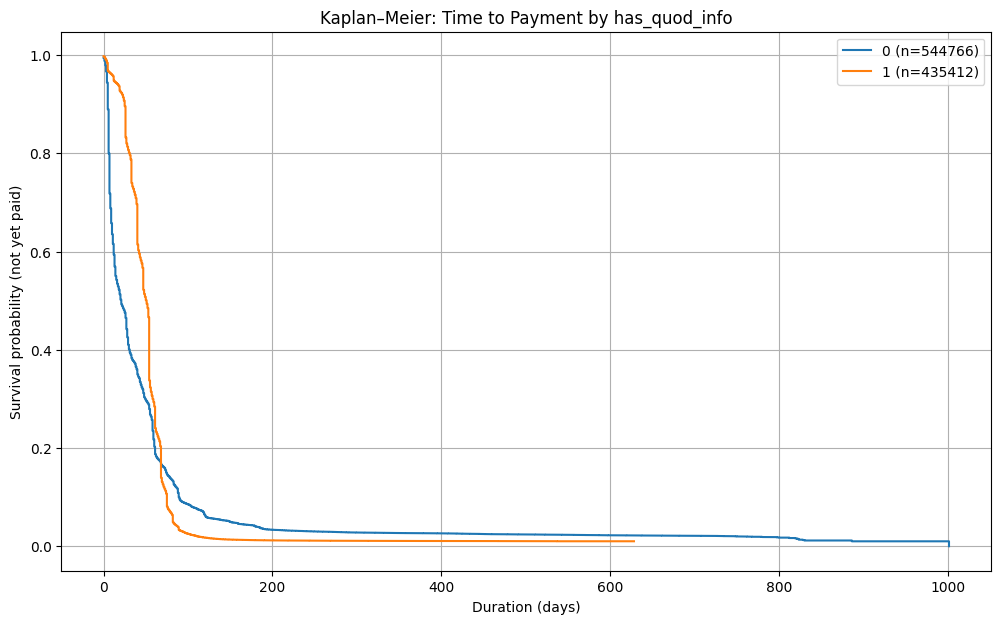

[0, 1]

In [34]:
plot_km_curve_category('has_quod_info', assets_duration_all)

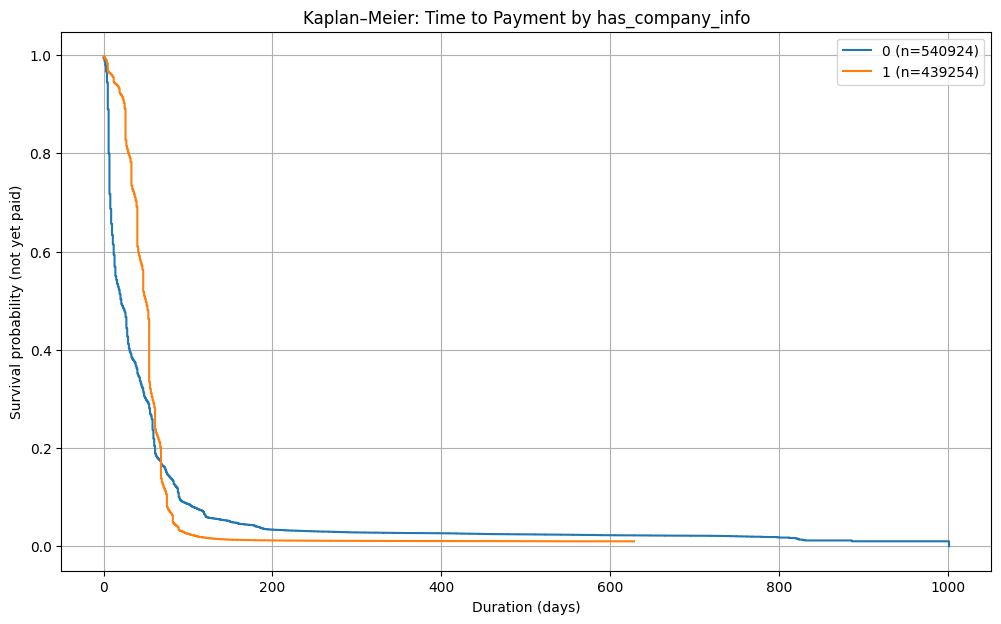

[0, 1]

In [35]:
plot_km_curve_category('has_company_info', assets_duration_all)

testing the association of these variables (Cramer's Phi from contigency table), we can also check that they are indeed very similar

In [36]:
from scipy.stats import chi2_contingency
table = pd.crosstab(assets_duration_all.has_company_info, assets_duration_all.has_quod_info)
chi2, p, dof, expected = chi2_contingency(table)
phi = np.sqrt(chi2 / assets_duration_all.shape[0])
print(phi)
print (table)

0.9920979654634042
has_quod_info          0       1
has_company_info                
0                 540924       0
1                   3842  435412


---

Analyzing quod_score feature, it can be seen that most of the companies that have a score are at 920 mark 

In [37]:
assets_duration_all['quod_score'].describe()

count    980178.000000
mean        408.553122
std         458.129800
min          -1.000000
25%          -1.000000
50%          -1.000000
75%         920.000000
max         962.000000
Name: quod_score, dtype: float64

In [38]:
assets_duration_all.loc[assets_duration_all.quod_score != -1].quod_score.describe()

count    435412.000000
mean        920.965770
std           7.116893
min         334.000000
25%         920.000000
50%         920.000000
75%         920.000000
max         962.000000
Name: quod_score, dtype: float64

And it is indeed more than 75% of assets of the sellers in assets table got this score!

In [39]:
assets_duration_all.groupby('quod_score')['asset_id'].count()

quod_score
-1.0      544766
 334.0         1
 758.0         3
 799.0         8
 858.0         7
 903.0      4116
 920.0    419540
 962.0     11737
Name: asset_id, dtype: int64

In [40]:
assets_duration_all['score_bin'] = np.where(assets_duration_all['quod_score'] == -1, 'null_score', 
         np.where(assets_duration_all['quod_score'] < 920, 'low_score', 'high_score'))

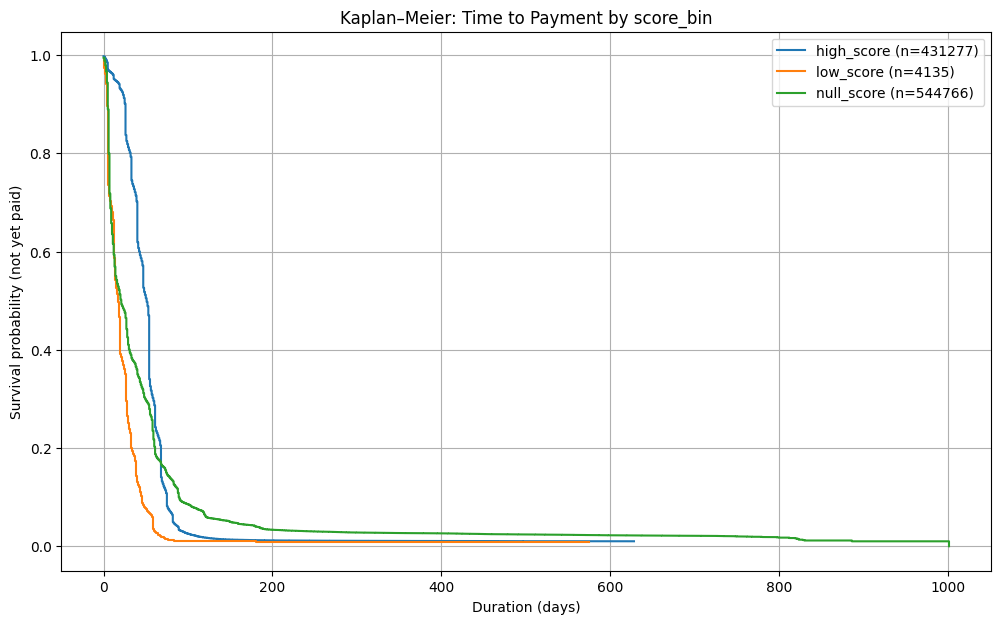

['high_score', 'low_score', 'null_score']

In [41]:
plot_km_curve_category('score_bin', assets_duration_all)

---

Maling the same rationale for presumed_revenue, an identifical curve is obtained, with most of the ones who received score 920 also had 12868800 as presumed revenue.

In [42]:
assets_duration_all.loc[assets_duration_all.presumed_revenue != -1]['presumed_revenue'].describe()

count    4.354120e+05
mean     1.321412e+08
std      3.036804e+07
min      3.929525e+05
25%      1.286888e+08
50%      1.286888e+08
75%      1.286888e+08
max      3.000000e+08
Name: presumed_revenue, dtype: float64

In [43]:
assets_duration_all.groupby('presumed_revenue')['asset_id'].count()

presumed_revenue
-1.000000e+00    544766
 3.929525e+05         7
 1.017922e+06         1
 1.053157e+06         3
 5.681685e+06         8
 5.976400e+06      4116
 1.286888e+08    419540
 3.000000e+08     11737
Name: asset_id, dtype: int64

In [44]:
assets_duration_all['revenue_group'] = np.where(
    assets_duration_all['presumed_revenue'] == -1, 'null_revenue',
    np.where(
        assets_duration_all['presumed_revenue'] < 12868800, 'low_revenue',  # ≤ 1.2 MM
        'high_revenue'  # > 1.2 MM
    )
)
 

In [45]:
assets_duration_all.groupby(['revenue_group'])['asset_id'].count()

revenue_group
high_revenue    431277
low_revenue       4135
null_revenue    544766
Name: asset_id, dtype: int64

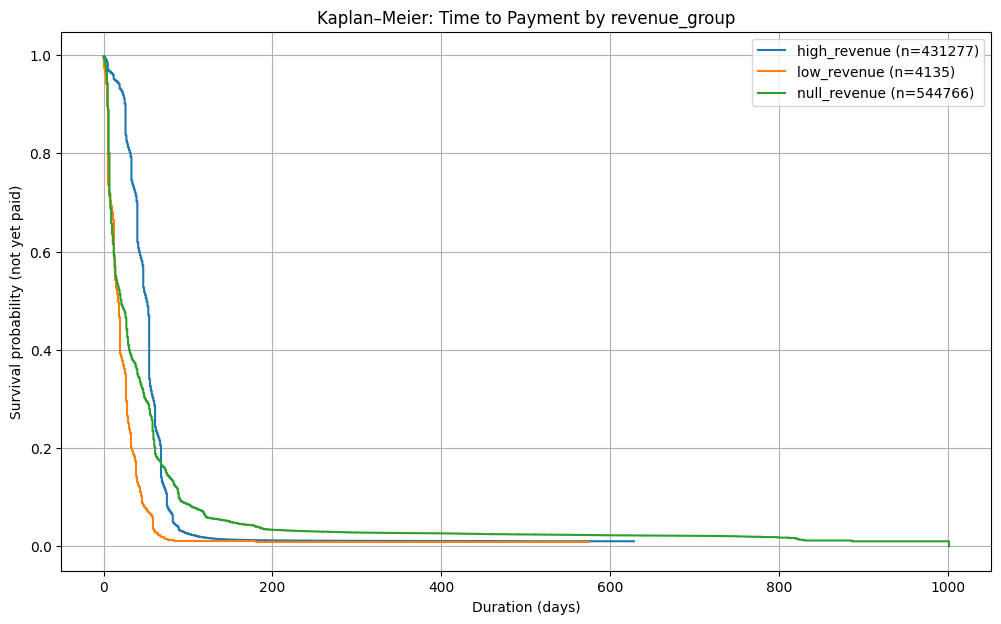

['high_revenue', 'low_revenue', 'null_revenue']

In [46]:
plot_km_curve_category('revenue_group', assets_duration_all)

We will use only the segmentation proposed for score_quod as presumed revenue got the same result

In [47]:
assets_duration_all.tax_id.value_counts()

tax_id
60259422305974    419540
14133781557079    269343
00925347588806     89567
32000772773675     62265
87924474238085     42131
                   ...  
99881788189631         1
87558830246197         1
28140959347687         1
16149631369090         1
65071673858838         1
Name: count, Length: 642, dtype: int64

---

In [48]:
def add_quod_info(duration, quod): 
    """
    This function adds quod_score in the durations dataframe, after deduplication, then create flags for missing values in score_quod and presumed_revenue
    fields (labeled -1)
    """    
    quod = quod.loc[quod.groupby("tax_id")["created_at"].idxmax()].drop('created_at', axis=1)
    df = duration.merge(quod, on='tax_id', how='left')
    for i in ['quod_score', 'presumed_revenue']:
        df['quod_score'] = np.where(df['quod_score'].isna(), -1, df['quod_score'])
        df['presumed_revenue'] = np.where(df['presumed_revenue'].isna(), -1, df['presumed_revenue'])
    df['has_quod_info'] = np.where ((df['quod_score'] == -1) & (df['presumed_revenue'] == -1) , 0, 1)
    return df   

    